In [83]:
import numpy as np
import pandas as pd
import sys
sys.path.append("..")
from utils import bootcampviztools as bt
import seaborn as sns
import matplotlib.pyplot as plt

# Problema de negocio

El objetivo de este proyecto es desarrollar un modelo de Machine Learning capaz de predecir si un paciente ha sufrido un ataque cardíaco (`HadHeartAttack`) en función de variables demográficas, hábitos de salud y condiciones médicas.

Este problema es un problema de clasificación binaria, donde:

- Clase 0: el paciente no ha sufrido un ataque cardíaco
- Clase 1: el paciente ha sufrido un ataque cardíaco

Este modelo podría utilizarse como herramienta de apoyo en entornos clínicos para identificar pacientes con alto riesgo cardiovascular y facilitar la toma de decisiones médicas preventivas.

In [84]:
df = pd.read_csv ("../data/heart_2022_with_nans.csv")
df.head(10)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No
5,Alabama,Male,Poor,1.0,0.0,Within past year (anytime less than 12 months ...,No,7.0,NaN,Yes,...,1.80,84.82,26.08,No,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No
6,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,62.60,22.96,Yes,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
7,Alabama,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,1.63,73.48,27.81,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
8,Alabama,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,NaN,No,...,1.70,NaN,NaN,No,Yes,No,No,"Yes, received tetanus shot but not sure what type",No,No
9,Alabama,Female,Good,1.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.68,81.65,29.05,Yes,NaN,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinCancer              44

In [86]:
df.describe()

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,434205.000000,436065.000000,439679.000000,416480.000000,403054.000000,396326.000000
mean,4.347919,4.382649,7.022983,1.702691,83.074470,28.529842
std,8.688912,8.387475,1.502425,0.107177,21.448173,6.554889
min,0.000000,0.000000,1.000000,0.910000,22.680000,12.020000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.130000
50%,0.000000,0.000000,7.000000,1.700000,80.740000,27.440000
75%,3.000000,5.000000,8.000000,1.780000,95.250000,31.750000
max,30.000000,30.000000,24.000000,2.410000,292.570000,99.640000


- Variables como BMI, WeightInKilograms y PhysicalHealthDays presentan una alta variabilidad.
- La media de SleepHours se sitúa en torno a valores normales, lo que indica que la mayoría de pacientes tienen hábitos de sueño razonables.
- Se detectan posibles valores extremos en variables como BMI y WeightInKilograms, lo que sugiere la presencia de outliers.
- La diferencia entre el count y el número total de observaciones confirma la existencia de valores faltantes en algunas variables.

En general, las variables numéricas presentan rangos coherentes y contienen información relevante para el modelado.

## Análisis de variables

|Columna|Descripción|Tipo|Categorías|
|:-----:|:-----:|:-----:|:-----:|
|State|Estado de residencia de la persona encuestada en USA|Categórica nominal|Estados y territorios de USA|
|Sex|Género de la persona encuestada|Categórica nominal|Female, Male|
|General Health|Estado general de la salud|Categórica ordinal|Poor,Fair,Good,Very good,Excellent|
|Physical Health Days|Días con mala salud física de los últimos 30 días|Numérica discreta|Días(0-30)|
|Mental Health Days|Días con mala salud mental de los últimos 30 días|Numérica discreta|Días(0-30)|
|Last Checkup Time|Tiempo desde el último chequeo|Categórica ordinal|<1 year, 1-2 years, >5 years, Never|
|Physical Activities|Si realiza actividad física o no|Booleana|Yes/No|
|Sleep Hours|Horas de sueño diario|Numérica continua|Horas|
|Removed Teeth|Cantidad de dientes quitados|Categórica ordinal|NaN,1-5,6+,All|
|Had Heart Attack|Si ha sufrido o no un ataque al corazón|Booleana|Yes/No|
|Had Angina|Si ha sufrido una angina de pecho|Booleana|Yes/No|
|Had Stroke|Si ha sufrido un derrame cerebral|Booleana|Yes/No|
|Had Asthma|Si tiene asma o no|Booleana|Yes/No|
|Had Skin Cancer|Si ha sufrido cáncer de piel|Booleana|Yes/No|
|Had COPD|Si tiene EPOC|Booleana|Yes/No|
|Had Depressive Disorder|Si ha sido diagnosticado de trastorno depresivo|Booleana|Yes/No|
|Had Kidney Disease|Si tiene problemas renales|Booleana|Yes/No|
|Had Arthritis|Diagnóstico de artritis|Booleana|Yes/No|
|Had Diabetes|Diagnóstico de diabetes|Categórica nominal|Yes, No, Borderline, During Pregnancy|
|Deaf Or Hard Of Hearing|Problemas auditivos|Booleana|Yes/No|
|Blind Or Vision Difficulty|Problemas visuales|Booleana|Yes/No|
|Difficulty Concentrating|Dificultad para concentrarse|Booleana|Yes/No|
|Difficulty Walking|Dificultad para andar|Booleana|Yes/No|
|Difficulty Dressing Bathing|Dificultad para vestirse o bañarse|Booleana|Yes/No|
|Difficulty Errands|Dificultad para realizar recados solo|Booleana|Yes/No|
|Smoker Status|Estado respecto al hábito de fumar|Categórica ordinal|Never, Former, Current (some days), Current (every day)|
|ECigarette Usage|Uso de cigarrillos electrónicos|Categórica ordinal|Never, Former, Current (some days), Current (every day)|
|Chest Scan|Se se ha realizado un escáner torácico|Booleana|Yes/No|
|Race Ethnicity Category|Grupo racial o étnico|Categórica nominal|White, Black, Hispanic, etc.|
|Age Category|Edad de la persona encuestada|Categórica ordinal|Rangos de edad|
|Height In Meters|Altura de la persona encuestada|Numérica continua|Metros|
|Weight In Kilograms|Peso de la persona encuestada|Numérica continua|kg|
|BMI|Índice de Masa Corporal|Numérica continua|kg|
|Alcohol Drinkers|Consumo de alcohol|Booleana|Yes/No|
|HIV Testing|Si se ha realizado el test de VIH|Booleana|Yes/No|
|Flu Vax Last 12|Si se ha puesto la vacuna de la gripe en los últimos 12 meses|Booleana|Yes/No|
|Pneumo Vax Ever|Si le han puesto la vacuna neumocócica alguna vez|Booleana|Yes/No|
|Tetanus Last 10 Tdap|Si le han puesto la vacuna antitetánica (Tdap) en los últimos 10 años|Categórica nominal|Yes, No, Don't know|
|High Risk Last Year|Conductas de alto riesgo durante el último año|Booleana|Yes/No|
|CovidPos|Resultado positivo en una prueba de COVID-19|Categórica nominal|Yes, No, Don't know|

In [87]:
target = "HadHeartAttack"

In [88]:
df["HadHeartAttack"].value_counts(normalize=True)*100


HadHeartAttack
No     94.320318
Yes     5.679682
Name: proportion, dtype: float64

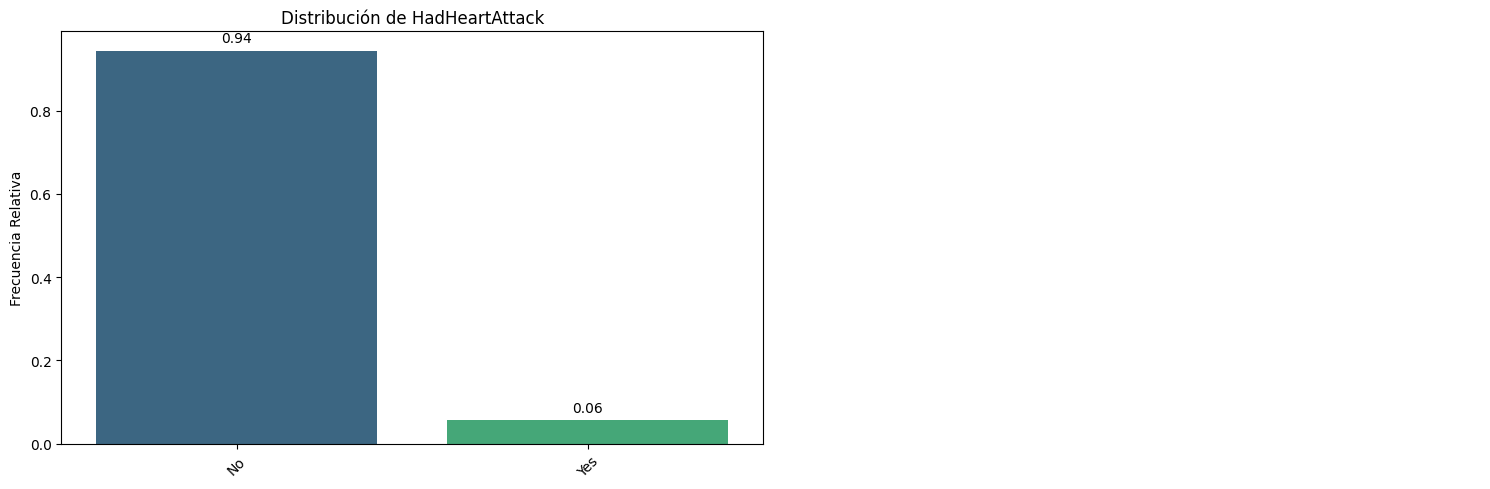

In [89]:
bt.pinta_distribucion_categoricas (df, [target], relativa= True, mostrar_valores=True)

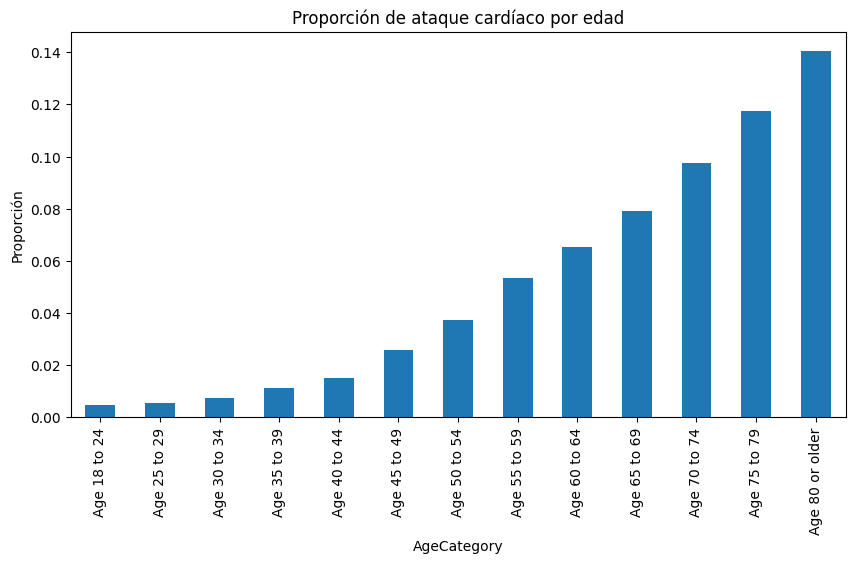

In [90]:
pd.crosstab(df["AgeCategory"], df["HadHeartAttack"], normalize="index")["Yes"].plot(kind="bar", figsize=(10,5))

plt.title("Proporción de ataque cardíaco por edad")
plt.ylabel("Proporción")
plt.show()

### Análisis del target

- La variable objetivo es HadHeartAttack, que indica si el paciente ha sufrido un ataque cardíaco.

- Se observa un desbalance en las clases, con una proporción menor de pacientes que han sufrido un ataque cardíaco.

- El riesgo aumenta significativamente con la edad, lo que indica que AgeCategory es un predictor relevante.

In [91]:
df.nunique()

State                          54
Sex                             2
GeneralHealth                   5
PhysicalHealthDays             31
MentalHealthDays               31
LastCheckupTime                 4
PhysicalActivities              2
SleepHours                     24
RemovedTeeth                    4
HadHeartAttack                  2
HadAngina                       2
HadStroke                       2
HadAsthma                       2
HadSkinCancer                   2
HadCOPD                         2
HadDepressiveDisorder           2
HadKidneyDisease                2
HadArthritis                    2
HadDiabetes                     4
DeafOrHardOfHearing             2
BlindOrVisionDifficulty         2
DifficultyConcentrating         2
DifficultyWalking               2
DifficultyDressingBathing       2
DifficultyErrands               2
SmokerStatus                    4
ECigaretteUsage                 4
ChestScan                       2
RaceEthnicityCategory           5
AgeCategory   

In [92]:
print (df.duplicated().sum())

157


In [93]:
df = df.drop_duplicates()

In [94]:
df.duplicated().sum()

np.int64(0)

## Tratamiento de duplicados

- Se han detectado 157 registros duplicados en el dataset.

- Estos registros han sido eliminados para evitar que el modelo aprenda patrones repetidos que puedan sesgar el entrenamiento.

In [95]:
porcentaje_nulos = (df.isna().mean() * 100).sort_values(ascending=False)

porcentaje_nulos

TetanusLast10Tdap            18.511152
PneumoVaxEver                17.280521
HIVTesting                   14.828024
ChestScan                    12.562504
CovidPos                     11.375471
HighRiskLastYear             11.343783
BMI                          10.935221
FluVaxLast12                 10.556773
AlcoholDrinkers              10.433845
WeightInKilograms             9.423226
ECigaretteUsage               7.981123
SmokerStatus                  7.936626
HeightInMeters                6.405978
DifficultyErrands             5.733131
DifficultyConcentrating       5.414911
DifficultyWalking             5.363672
DifficultyDressingBathing     5.341873
BlindOrVisionDifficulty       4.813529
DeafOrHardOfHearing           4.607450
RaceEthnicityCategory         3.157031
RemovedTeeth                  2.551829
PhysicalHealthDays            2.454520
AgeCategory                   2.038092
MentalHealthDays              2.036519
LastCheckupTime               1.865498
SleepHours               

In [96]:
cols_to_drop = df.columns[df.isna().mean() > 0.5].tolist()

print(f"Se eliminarán {len(cols_to_drop)} columnas:")
for col in cols_to_drop:
    print("-", col)

df.drop(columns=cols_to_drop, inplace=True)

Se eliminarán 0 columnas:


## Eliminación de columnas con alto porcentaje de valores faltantes

- Se evaluó el porcentaje de valores faltantes en cada columna.

- No se encontraron columnas con más del 50% de valores nulos, por lo que no fue necesario eliminar ninguna columna en este paso.

In [97]:
cols_eliminar = ["State", 
                 "DifficultyDressingBathing", 
                 "TetanusLast10Tdap", 
                 "CovidPos", 
                 "ChestScan", 
                 "HIVTesting", 
                 "PneumoVaxEver", 
                 "RemovedTeeth", 
                 "RaceEthnicityCategory", 
                 "LastCheckupTime", 
                 "FluVaxLast12", 
                 "HighRiskLastYear", 
                 "DifficultyErrands", 
                 "BlindOrVisionDifficulty", 
                 "DeafOrHardOfHearing"]

df = df.drop (columns = cols_eliminar)

Decidimos eliminar columnas que no aportan un valor predictivo ya que, entre ellas, tienen demasiados nulos, son difíciles de interpretar, están desbalanceadas o no tienen relación directa con la cuestión que nos planteamos.

In [98]:
df.columns

Index(['Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays',
       'PhysicalActivities', 'SleepHours', 'HadHeartAttack', 'HadAngina',
       'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DifficultyConcentrating', 'DifficultyWalking',
       'SmokerStatus', 'ECigaretteUsage', 'AgeCategory', 'HeightInMeters',
       'WeightInKilograms', 'BMI', 'AlcoholDrinkers'],
      dtype='object')

In [99]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numéricas:", numerical_cols)
print("Categóricas:", categorical_cols)

Numéricas: Index(['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours',
       'HeightInMeters', 'WeightInKilograms', 'BMI'],
      dtype='object')
Categóricas: Index(['Sex', 'GeneralHealth', 'PhysicalActivities', 'HadHeartAttack',
       'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DifficultyConcentrating', 'DifficultyWalking',
       'SmokerStatus', 'ECigaretteUsage', 'AgeCategory', 'AlcoholDrinkers'],
      dtype='object')


In [100]:
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median()) #Imputamos la mediana porque hay outliers

In [101]:
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

In [102]:
total_nulos = df.isna().sum().sum() #Queremos saber el número total de nulos del dataset
total_nulos

np.int64(0)

In [103]:
print ((df.isna().sum().sort_values(ascending=False)))

Sex                        0
GeneralHealth              0
PhysicalHealthDays         0
MentalHealthDays           0
PhysicalActivities         0
SleepHours                 0
HadHeartAttack             0
HadAngina                  0
HadStroke                  0
HadAsthma                  0
HadSkinCancer              0
HadCOPD                    0
HadDepressiveDisorder      0
HadKidneyDisease           0
HadArthritis               0
HadDiabetes                0
DifficultyConcentrating    0
DifficultyWalking          0
SmokerStatus               0
ECigaretteUsage            0
AgeCategory                0
HeightInMeters             0
WeightInKilograms          0
BMI                        0
AlcoholDrinkers            0
dtype: int64


## Tratamiento de valores faltantes

Los valores faltantes han sido imputados utilizando diferentes estrategias según el tipo de variable:

- Variables numéricas: imputación mediante la mediana, ya que es robusta frente a valores extremos.
- Variables categóricas: imputación mediante la moda, preservando la categoría más frecuente.

Este enfoque permite mantener el tamaño del dataset y evitar la pérdida de información relevante.

Tras la imputación, el dataset no contiene valores nulos y está preparado para el modelado.

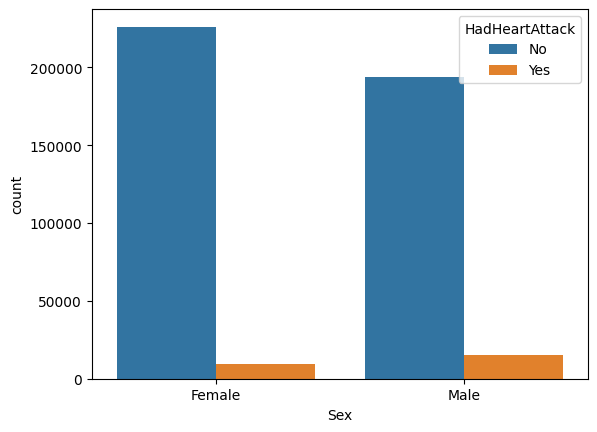

In [104]:
sns.countplot(x="Sex", hue=target, data=df)
plt.show()

### CONCLUSIONES TARGET

Vemos una distribución muy desbalanceada, siendo el 94% de las personas encuestadas las que no han sufrido un ataque al corazón frente a casi el 6% que si que lo han sufrido. Asimismo, observamos como hay más hombres que mujeres que han sufrido un ataque al corazón.

In [105]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print (f"{col}: {df[col].nunique()} valores únicos")

Sex: 2 valores únicos
GeneralHealth: 5 valores únicos
PhysicalActivities: 2 valores únicos
HadHeartAttack: 2 valores únicos
HadAngina: 2 valores únicos
HadStroke: 2 valores únicos
HadAsthma: 2 valores únicos
HadSkinCancer: 2 valores únicos
HadCOPD: 2 valores únicos
HadDepressiveDisorder: 2 valores únicos
HadKidneyDisease: 2 valores únicos
HadArthritis: 2 valores únicos
HadDiabetes: 4 valores únicos
DifficultyConcentrating: 2 valores únicos
DifficultyWalking: 2 valores únicos
SmokerStatus: 4 valores únicos
ECigaretteUsage: 4 valores únicos
AgeCategory: 13 valores únicos
AlcoholDrinkers: 2 valores únicos


### Conclusión — Cardinalidad

- Las variables categóricas presentan baja y media cardinalidad.

- La mayoría de variables tienen solo 2 categorías (Yes/No), lo que facilita su uso en modelos de Machine Learning.

- No se han detectado variables con cardinalidad extremadamente alta que puedan indicar identificadores únicos o problemas para el modelado.

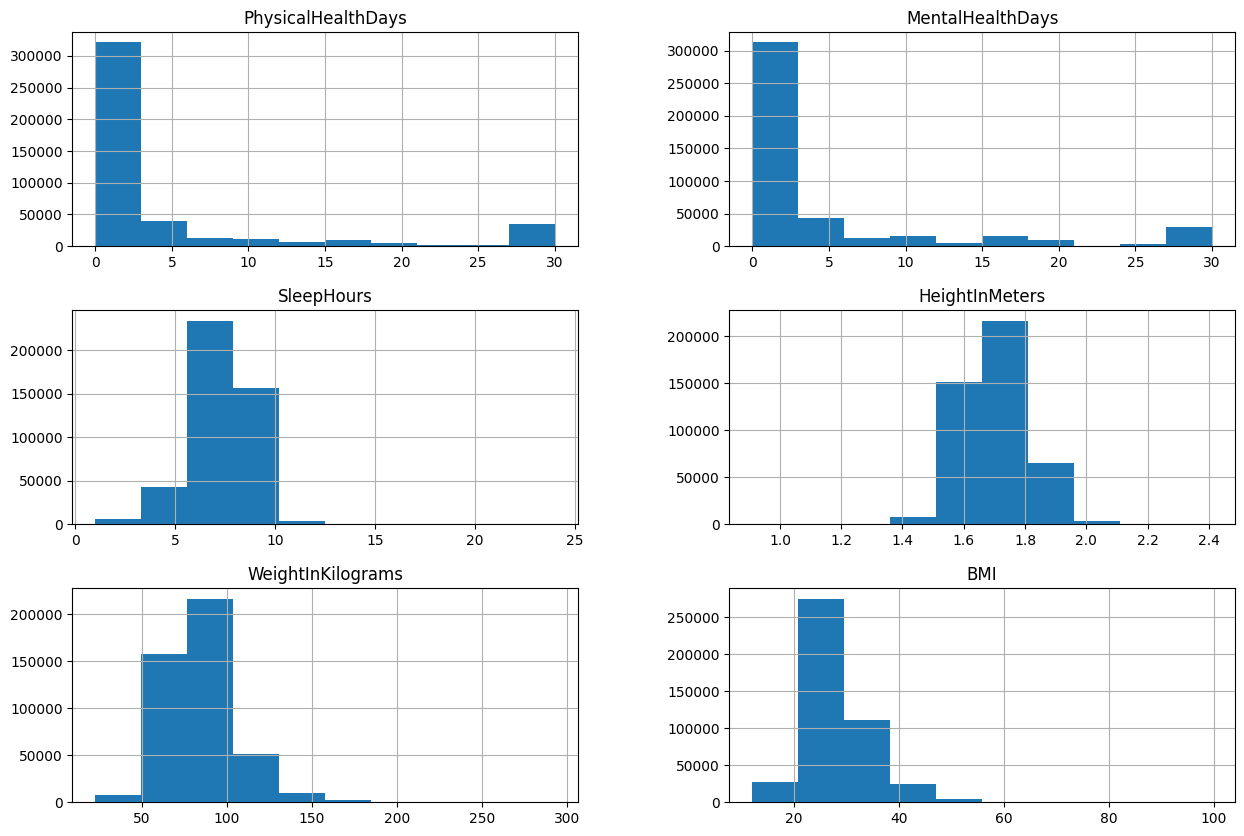

In [106]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[numerical_cols].hist(figsize=(15,10))
plt.show()

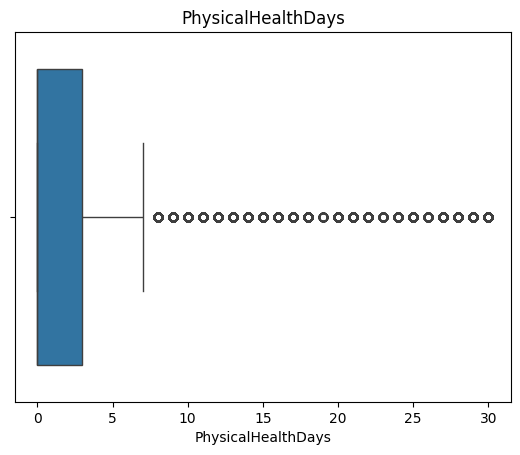

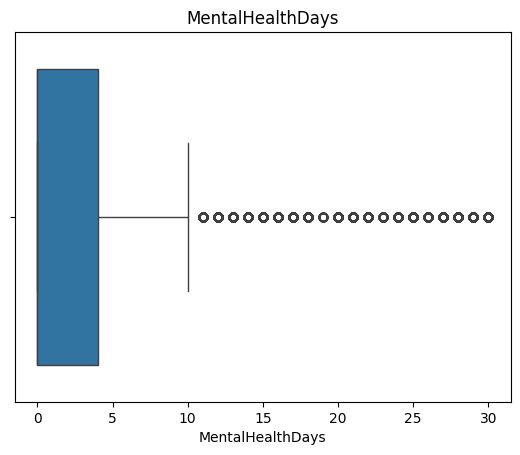

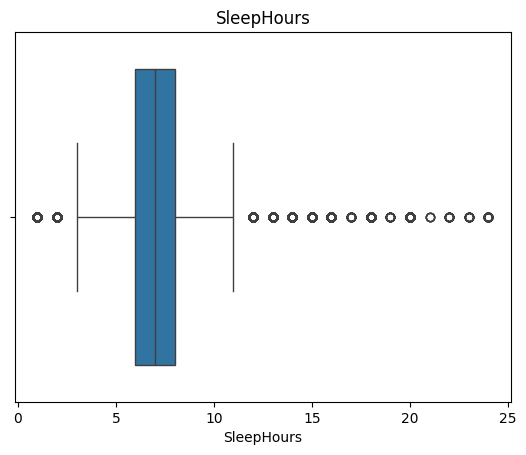

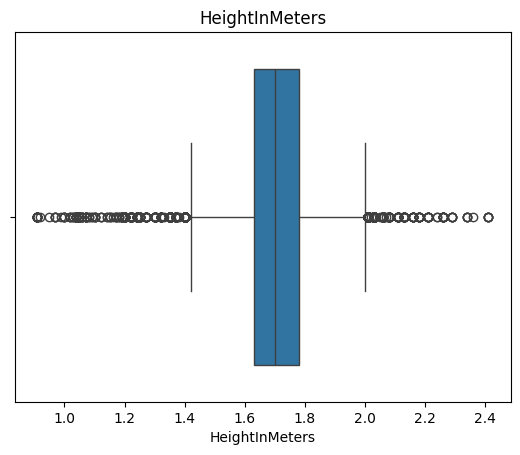

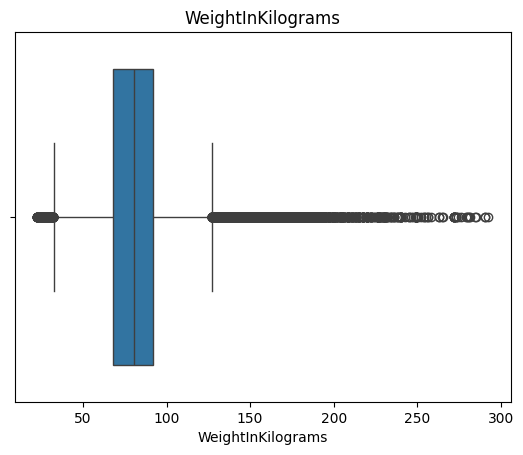

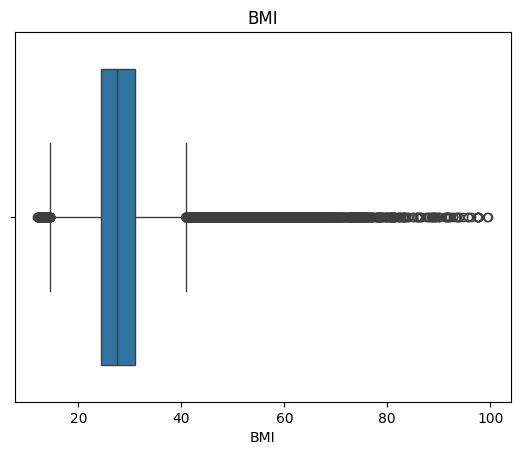

In [107]:
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

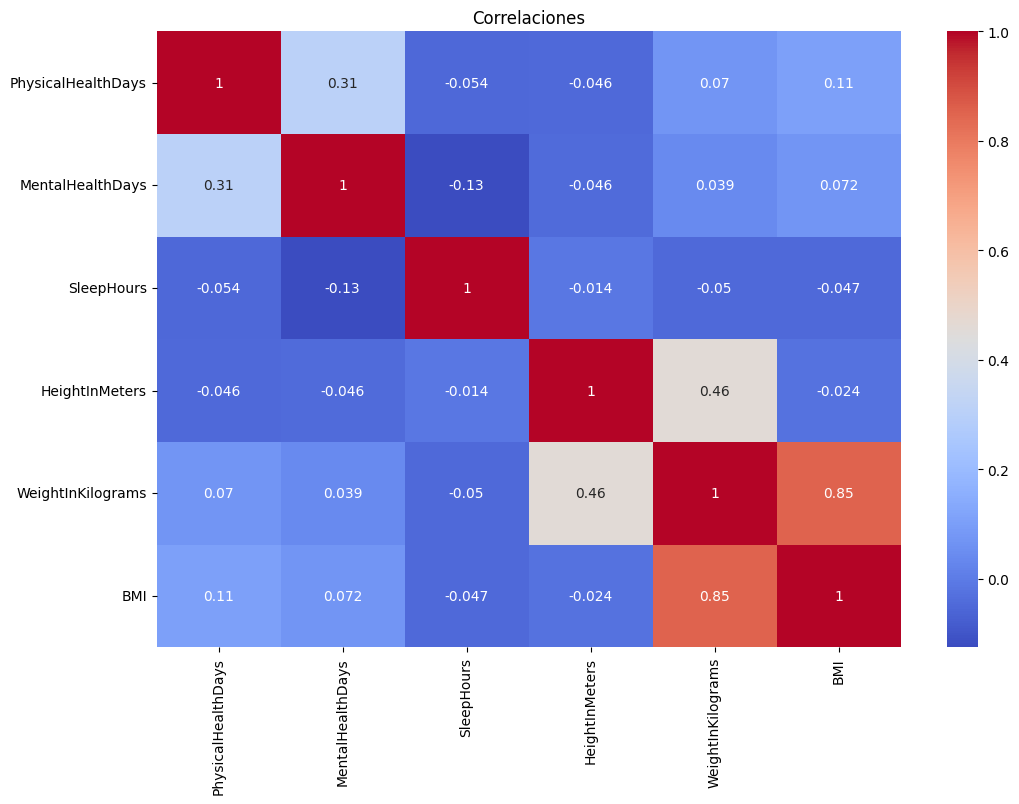

In [108]:
plt.figure(figsize=(12,8))
sns.heatmap (df[numerical_cols].corr(), cmap="coolwarm", annot=True)
plt.title ("Correlaciones")
plt.show()

### Conclusiones

- El dataset presenta buena calidad tras la eliminación de variables irrelevantes y duplicados.

- Se observa un desbalance en la variable objetivo, lo que deberá tenerse en cuenta durante el modelado.

- Variables como la edad, BMI, tabaquismo y condiciones médicas parecen ser predictores relevantes.